<strong><h1><center> KMeans

In [9]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer

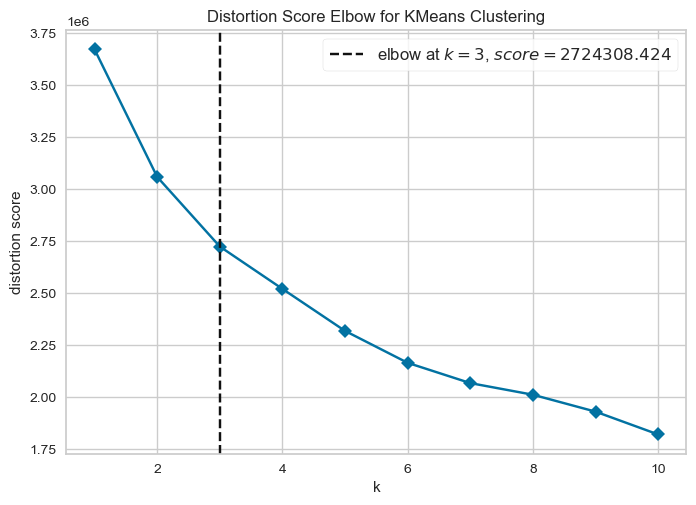

In [10]:
data_path = '../../../../data/processed_data/main_datasets/data_with_generated_features.csv'
data = pd.read_csv(data_path)

X = data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(1, 11), timings=False)
visualizer.fit(X_scaled)
visualizer.show();

Как мы видим, точка в которой происходит значительное снижение скорости уменьшения inertia находится при количестве кластеров равном 3

In [7]:
n_clusters = visualizer.elbow_value_

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X_scaled)

data['Cluster'] = kmeans.labels_

In [8]:
output_path = '../../../../data/processed_data/train_models_data/data_without_PCA/data_with_generated_features/KMeans_generated_features.csv'
data.to_csv(output_path, index=False)